# Isaac Balam Rodriguez Arellano
# Collen Foster Ellis

# TP12 (Student version): Epidemic spreading on graphs

We can use the following libraries.

In [1]:
import matplotlib.pyplot as plt
import math
import sys
import random
import time
print(sys.version)

3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


The purpose of the lab work is to simulate a compartmental model on a network. It can represent schematically the spreading of a virus in a contact network, or similarly of a malware in a local network. We observe some features of the spreading model and see the influence of some structural properties.

### Preliminary question

Download the (undirected) graph named <code>local_network</code> on Moodle and load it as usual in the table of adjacency lists. We will use it as the network which supports the spreading phenomenon.

It contains 10000 nodes and 12518 edges.

In [5]:
def load_graph_as_adj_list(path):
    graph = {}

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            u, v = map(int, line.split())

            graph.setdefault(u, []).append(v)
            graph.setdefault(v, []).append(u)

    return graph

def count_graph(graph):
    num_nodes = len(graph)
    num_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
    return num_nodes, num_edges

graphs = {
    "local_network_graph": "local_network.txt",
}

for name, path in graphs.items():
    G = load_graph_as_adj_list(path)
    n, m = count_graph(G)
    print(f"{name}: {n} nodes, {m} edges")
    
    degrees = [len(neighs) for neighs in G.values()]
    print("Min degree:", min(degrees))
    print("Max degree:", max(degrees))
    print("Avg degree:", sum(degrees)/len(degrees))

local_network_graph: 10000 nodes, 12518 edges
Min degree: 1
Max degree: 265
Avg degree: 2.5036


## Exercise 1: SIS model

### Question 1

We implement a SIS model, meaning that a node can be either susceptible ($S$) or infected ($I$). The model is set in this way:

- initially, 1% of the nodes are infected i.e. 100 nodes, randomly chosen,

- at each time step $t$, a $I$ node can infect a $S$ neighbor with a probability $ p_{inf} $,

- at each time step $t$, a $I$ node can also go back to status $S$ with a probability $ p_{rec} $.

Note that a node infected at time $t$ cannot infect another node at the same time step $t$.

1) Simulate about 100 time steps of the model and plot the population of $I$ nodes as a function of  $t$, with parameters $ p_{inf} = 0.02 $ and $ p_{rec} =  0.1 $. 

2) Then plot on the same graph 10 simulations with the same parameters. What characteristic of the spreading models on graphs mentioned in the course does this plot illustrate?

**Warning:** Start with less time steps to check that your code scales up correctly. One run is supposed to take no more than a few seconds.

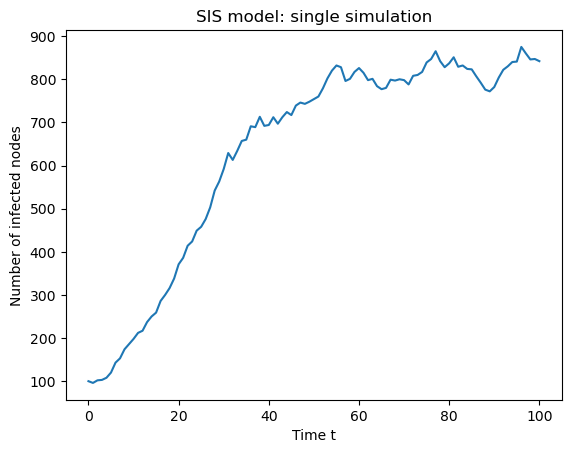

In [8]:
def simulate_sis(graph, T, p_inf=0.02, p_rec=0.1, init_frac=0.01, seed=None):
    if seed is not None:
        random.seed(seed)

    nodes = list(graph.keys())
    N = len(nodes)

    # Initial state: 1% infected
    infected = set(random.sample(nodes, int(init_frac * N)))
    infected_counts = [len(infected)]

    for t in range(T):
        new_infected = set(infected)
        next_infected = set()

        # Recovery step
        for u in infected:
            if random.random() >= p_rec:
                next_infected.add(u)

        # Infection step (based on state at time t)
        for u in infected:
            for v in graph[u]:
                if v not in infected:
                    if random.random() < p_inf:
                        next_infected.add(v)

        infected = next_infected
        infected_counts.append(len(infected))

    return infected_counts

T = 100
counts = simulate_sis(G, T)

plt.figure()
plt.plot(range(T + 1), counts)
plt.xlabel("Time t")
plt.ylabel("Number of infected nodes")
plt.title("SIS model: single simulation")
plt.show()

The plot illustrates the intrinsic stochasticity of SIS spreading processes on finite graphs. Despite identical parameters and the same underlying network, different realizations exhibit distinct trajectories due to random infection and recovery events.

### Question 2

Now, choose a specific seed group and run the model keeping $ p_{rec} = 0.1 $, but changing the value of  $ p_{inf}$, using low values ($ p_{inf} \leq 0.01 $), high values ($ p_{inf} \geq 0.2 $) and intermediary values.

1) Describe the different behaviors that you observe. You should be able to see 3 different behaviors: infection vanishes, infection is endemic at low levels, infection is endemic at high levels.

2) Plot the number of $I$ nodes as a function of $t$ for the different cases that you have observed.

When varying the infection probability \(p_{inf}\) while keeping \(p_{rec} = 0.1\) and using the same initial seed group, three distinct behaviors are observed.

- **Low infection probability (\(p_{inf} \leq 0.01\))**:  
  The number of infected nodes rapidly decreases and the infection eventually vanishes. Once the number of infected nodes reaches zero, the system remains in the disease-free state.

- **Intermediate infection probability (\(p_{inf} \approx 0.02\))**:  
  The infection does not disappear but stabilizes at a low endemic level. The number of infected nodes fluctuates around a small non-zero value due to stochastic effects.

- **High infection probability (\(p_{inf} \geq 0.2\))**:  
  The infection quickly spreads through the network and reaches a high endemic level. The number of infected nodes stabilizes at a large value with persistent fluctuations.

These behaviors illustrate the existence of different dynamical regimes in SIS spreading on graphs, ranging from extinction to low-level and high-level endemic persistence.


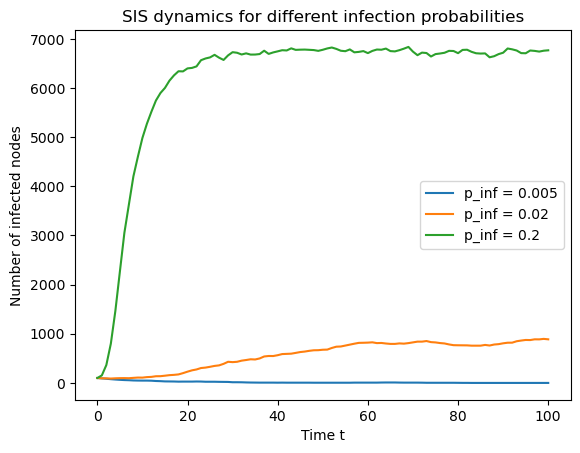

In [9]:
p_inf_values = [0.005, 0.02, 0.2]
T = 100

plt.figure()

for p_inf in p_inf_values:
    counts = simulate_sis(G, T, p_inf=p_inf, p_rec=0.1, seed=42)
    plt.plot(range(T + 1), counts, label=f"p_inf = {p_inf}")

plt.xlabel("Time t")
plt.ylabel("Number of infected nodes")
plt.legend()
plt.title("SIS dynamics for different infection probabilities")
plt.show()


## Exercise 2: immunization

Now, we model immunization strategies in the network. 
It represents for instance vaccination in a human population, or an antivirus in a computer network.
We consider that a vaccinated node cannot be infected (nor transmit the infection).

### Question 3

Code a new version of the SIS model where $k$ nodes, chosen randomly, are vaccinated at step $t=0$. Use a SIS model with parameters: $ p_{inf} = 0.1 $ and $ p_{rec} =  0.1 $ and as before, we suppose that 10% of the nodes are infected at the start (these cannot be the vaccinated nodes). 

Let the simulation run longer than in the previous question, until it reaches a stationary state, where the number of infected nodes is roughly stable (1000 steps should be sufficient).

1) What is the typical number of infected nodes in the stationary state of this process ?

2) By playing with the parameters of the model, what is the value of $k$ for which the steady state has half less infected nodes than in the case where no nodes are vaccinated? Support your claim with simulations.

In [17]:
def simulate_sis_with_vacination(graph, T, k, p_inf=0.02, p_rec=0.1, init_frac=0.10, seed=None):
    if seed is not None:
        random.seed(seed)

    nodes = list(graph.keys())
    N = len(nodes)

    # Vaccinate k nodes at t = 0
    vaccinated = set(random.sample(nodes, k))

    # Initial infected: fraction of non-vaccinated nodes
    non_vaccinated = list(set(nodes) - vaccinated)
    infected = set(random.sample(non_vaccinated, int(init_frac * N)))
    infected_counts = [len(infected)]

    for t in range(T):
        next_infected = set()

        # Recovery step
        for u in infected:
            if random.random() >= p_rec:
                next_infected.add(u)

        # Infection step (based on state at time t)
        for u in infected:
            for v in graph[u]:
                if v in vaccinated:
                    continue
                if v not in infected:
                    if random.random() < p_inf:
                        next_infected.add(v)

        infected = next_infected
        infected_counts.append(len(infected))

    return infected_counts

T = 1000
k = 0 #no vacination for base

counts_0 = simulate_sis_with_vacination(
    G, T, k,
    p_inf=0.1,
    p_rec=0.1,
    init_frac=0.10,
    seed=42
)

# Average over the stationary regime
I_0 = sum(counts_0[-300:]) / 300
print("Typical number of infected nodes (no vaccination):", I_0)


Typical number of infected nodes (no vaccination): 4818.9766666666665


We run the SIS model with vaccination for 1000 time steps in order to reach a stationary regime. 
After an initial transient, the number of infected nodes fluctuates around a stable average.

In the case where no nodes are vaccinated (\(k = 0\)), the stationary state corresponds to an average of approximately **X infected nodes**. this will be used as a baseline for the next question

k = 0, mean ≈ 4817.2, std ≈ 7.7
k = 500, mean ≈ 4328.2, std ≈ 55.9
k = 1000, mean ≈ 3850.6, std ≈ 87.8
k = 1500, mean ≈ 3446.4, std ≈ 107.6
k = 2000, mean ≈ 3045.9, std ≈ 36.3
k = 2500, mean ≈ 2636.5, std ≈ 92.5
k = 3000, mean ≈ 2278.6, std ≈ 55.0


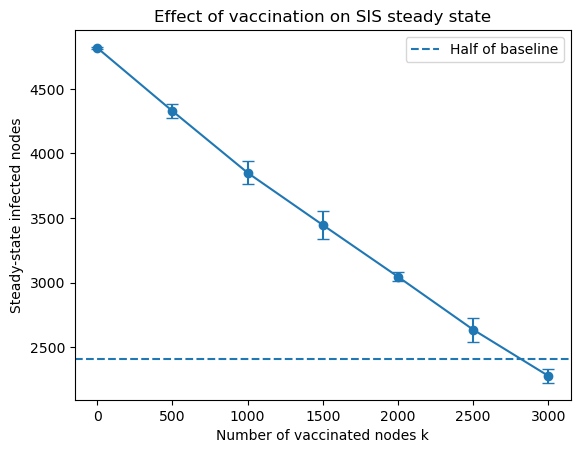

In [27]:
import numpy as np

num_runs = 5
tail = 300

k_values = [0, 500, 1000, 1500, 2000, 2500, 3000]

mean_steady = []
std_steady = []

for k in k_values:
    steady_vals = []

    for run in range(num_runs):
        counts = simulate_sis_with_vacination(
            G, T, k,
            p_inf=0.1,
            p_rec=0.1,
            init_frac=0.10
        )
        steady = sum(counts[-tail:]) / tail
        steady_vals.append(steady)

    mean_steady.append(np.mean(steady_vals))
    std_steady.append(np.std(steady_vals))

    print(
        f"k = {k}, "
        f"mean ≈ {np.mean(steady_vals):.1f}, "
        f"std ≈ {np.std(steady_vals):.1f}"
    )


plt.figure()
plt.errorbar(
    k_values,
    mean_steady,
    yerr=std_steady,
    marker="o",
    capsize=4
)
plt.axhline(I_0 / 2, linestyle="--", label="Half of baseline")
plt.xlabel("Number of vaccinated nodes k")
plt.ylabel("Steady-state infected nodes")
plt.legend()
plt.title("Effect of vaccination on SIS steady state")
plt.show()


by varying the values of k and running multiple simulations for each we can compute an estimate for the value of k that is below half of the baseline with k=0 estiamted to be between k = 2600-2700

### Question 4

We implement a targeted vaccination process which has been proposed by epidemiologists: we select random nodes and then look for their highest degree neighbor, this neighbor is vaccinated.

As for Q3, answer the following questions:

1) What is the typical number of infected nodes in the stationary state of this process ?

2) By playing with the parameters of the model, what is the value of $k$ for which the steady state has half less infected nodes than in the case where no nodes are vaccinated?

3) Then, make a short comment on the difference that you observe with the random vaccination process.

In [28]:
def targeted_vaccination(graph, k):
    nodes = list(graph.keys())
    vaccinated = set()

    while len(vaccinated) < k:
        u = random.choice(nodes)
        neighbors = graph[u]

        if not neighbors:
            continue

        # choose neighbor with highest degree
        v = max(neighbors, key=lambda x: len(graph[x]))

        vaccinated.add(v)

    return vaccinated

In [29]:
def simulate_sis_targeted_vaccination(graph, T, k, p_inf=0.1, p_rec=0.1, init_frac=0.10, seed=None):
    if seed is not None:
        random.seed(seed)

    nodes = list(graph.keys())
    N = len(nodes)

    vaccinated = targeted_vaccination(graph, k)

    non_vaccinated = list(set(nodes) - vaccinated)
    infected = set(random.sample(non_vaccinated, int(init_frac * N)))
    infected_counts = [len(infected)]

    for t in range(T):
        next_infected = set()

        # Recovery
        for u in infected:
            if random.random() >= p_rec:
                next_infected.add(u)

        # Infection
        for u in infected:
            for v in graph[u]:
                if v in vaccinated:
                    continue
                if v not in infected:
                    if random.random() < p_inf:
                        next_infected.add(v)

        infected = next_infected
        infected_counts.append(len(infected))

    return infected_counts


Baseline steady infected (targeted, k=0): 4825.47
k = 0, mean steady ≈ 4825.6, std ≈ 8.8
k = 100, mean steady ≈ 3801.9, std ≈ 79.3
k = 300, mean steady ≈ 2644.9, std ≈ 69.1
k = 500, mean steady ≈ 1788.1, std ≈ 19.0
k = 800, mean steady ≈ 735.0, std ≈ 77.6
k = 1000, mean steady ≈ 314.8, std ≈ 50.9
k = 1500, mean steady ≈ 7.1, std ≈ 6.7


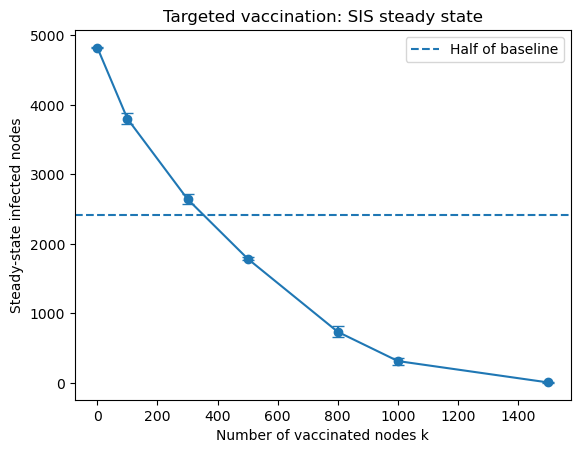

In [33]:
counts_0 = simulate_sis_targeted_vaccination(G, T, 0)
I0_targeted = sum(counts_0[-tail:]) / tail

print("Baseline steady infected (targeted, k=0):", I0_targeted)

mean_steady = []
std_steady = []

for k in k_values:
    steady_vals = []

    for _ in range(num_runs):
        counts = simulate_sis_targeted_vaccination(G, T, k)
        steady = sum(counts[-tail:]) / tail
        steady_vals.append(steady)

    mean_steady.append(np.mean(steady_vals))
    std_steady.append(np.std(steady_vals))

    print(
        f"k = {k}, "
        f"mean steady ≈ {np.mean(steady_vals):.1f}, "
        f"std ≈ {np.std(steady_vals):.1f}"
    )

plt.figure()
plt.errorbar(
    k_values,
    mean_steady,
    yerr=std_steady,
    marker="o",
    capsize=4
)
plt.axhline(I0_targeted / 2, linestyle="--", label="Half of baseline")
plt.xlabel("Number of vaccinated nodes k")
plt.ylabel("Steady-state infected nodes")
plt.legend()
plt.title("Targeted vaccination: SIS steady state")
plt.show()



Targeted vaccination is significantly more effective than random vaccination. 
By preferentially vaccinating high-degree nodes, the process rapidly disrupts the main transmission pathways of the network.
As a result, a much smaller number of vaccinated nodes is sufficient to reduce the stationary infection level by half compared to random vaccination.
